# Import libraries

In [1]:
import sys
github_repo_url = "https://github.com/AnnaEls/HAADF-STEM-image-denoising.git"
!git clone {github_repo_url}
sys.path.append('/content/HAADF-STEM-image-denoising')

Cloning into 'HAADF-STEM-image-denoising'...
remote: Enumerating objects: 913, done.
remote: Counting objects: 100% (509/509), done.
remote: Compressing objects: 100% (500/500), done.
remote: Total 913 (delta 250), reused 0 (delta 0), pack-reused 404 (from 2)
Receiving objects: 100% (913/913), 60.92 MiB | 12.54 MiB/s, done.
Resolving deltas: 100% (352/352), done.
Updating files: 100% (59/59), done.


In [ ]:
!pip install hyperspy
!pip install atomap

In [16]:
import numpy as np
import matplotlib.pyplot as plt
#import os
import pandas as pd
import h5py
import tifffile
from Utilities.Utils import convert
import hyperspy.api as hs
import atomap as am
#from Analysis.gaussian_detection_atomap import find_atoms, compare_sublattices_with_lattice_fp_classification, plot_atom_classification
from Analysis.gaussian_detection_atomap import find_atoms, compare_sublattices_with_lattice_fp_classification, plot_atom_classification

# Setting parameters

In [5]:
dataset_path = '/content/HAADF-STEM-image-denoising/Datasets/'
data_file = dataset_path + 'wei_atom_subset_WS2_contrast_variation.h5'

metadata_subset = pd.read_hdf(data_file, key="metadata")

with h5py.File(data_file, "r") as f:
    print("Top-level keys:", list(f.keys()))
    print("Images:", list(f["imgs"].keys()))
    print("Raw:", list(f["raw"].keys()))
    print("Coordinates:", list(f["coords"].keys()))

print("\nMetadata:")
display(metadata_subset)

Top-level keys: ['coords', 'imgs', 'metadata', 'raw']
Images: ['0123', '0124', '0125', '0126', '0127', '0128', '0129', '0130']
Raw: ['0123', '0124', '0125', '0126', '0127', '0128', '0129', '0130']
Coordinates: ['0123', '0124', '0125', '0126', '0127', '0128', '0129', '0130']

Metadata:


,key,Atoms/px,Material_orientation,Spacegroup,Type,contrast,dose_e-/Å²,peakintensity_e-,pixelsize_pm,probe_current_pA,resolution_pm,flybackerror,poisson_dB,randomdrift
123,0123,8.393051,WS2[0001],P63/mmc[194],experimental,0.159,116783.034798,2502.422276,15.46,22.33,98.0,NaN,NaN,NaN
124,0124,8.393051,WS2[0001],P63/mmc[194],experimental,0.133,116783.034798,2365.907658,15.46,22.33,98.0,NaN,NaN,NaN
125,0125,8.393051,WS2[0001],P63/mmc[194],experimental,0.101,116783.034798,2229.216597,15.46,22.33,98.0,NaN,NaN,NaN
126,0126,8.393051,WS2[0001],P63/mmc[194],experimental,0.060,116783.034798,3164.079849,15.46,22.33,98.0,NaN,NaN,NaN
127,0127,8.393051,WS2[0001],P63/mmc[194],experimental,0.048,116783.034798,4146.385107,15.46,22.33,98.0,NaN,NaN,NaN
128,0128,8.393051,WS2[0001],P63/mmc[194],experimental,0.037,116783.034798,4616.112008,15.46,22.33,98.0,NaN,NaN,NaN
129,0129,8.393051,WS2[0001],P63/mmc[194],experimental,0.109,116783.034798,2270.713104,15.46,22.33,98.0,NaN,NaN,NaN
130,0130,8.393051,WS2[0001],P63/mmc[194],experimental,0.087,116783.034798,2179.196693,15.46,22.33,98.0,NaN,NaN,NaN


In [6]:
key = "0128"

with h5py.File(data_file, "r") as f:
    img = f["imgs"][key][:]
    raw = f["raw"][key][:]
    coords = f["coords"][key][:]

print("Image shape:", img.shape)
print("Raw shape:", raw.shape)
print("Coordinates shape:", coords.shape)

Image shape: (256, 256)
Raw shape: (256, 256)
Coordinates shape: (297, 2)


In [13]:
SEPARATION = 4
MATCH_TOLERANCE = 5.0
LATTICE_TOLERANCE = 5.0
NEIGHBOR_RADIUS = 25

# Analysis

Image ID: 0123


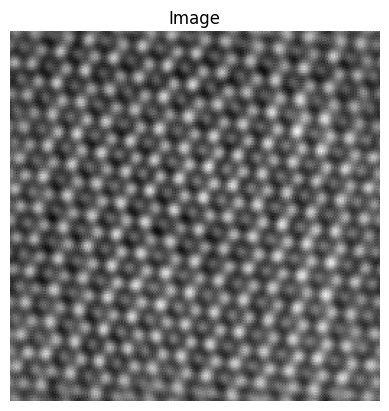

Image ID: 0124


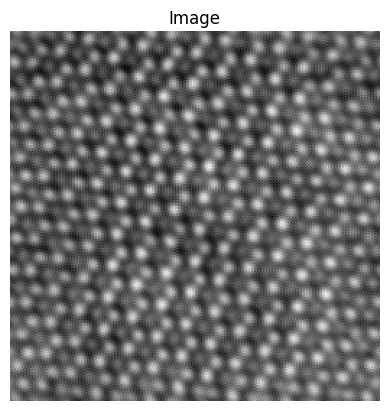

Image ID: 0129


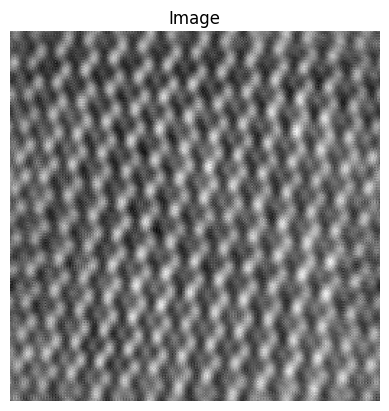

Image ID: 0125


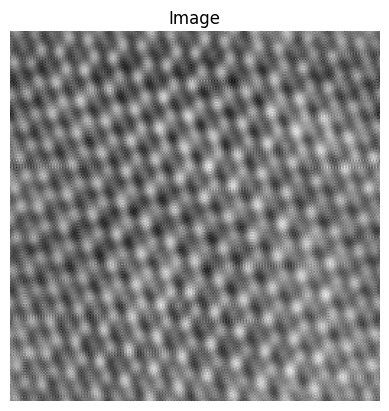

Image ID: 0130


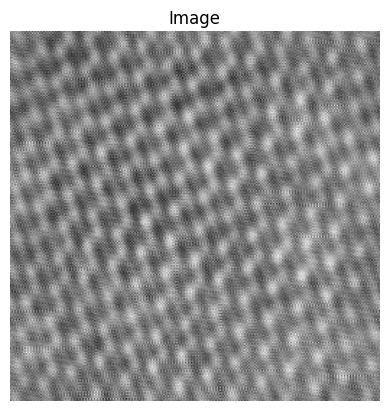

Image ID: 0126


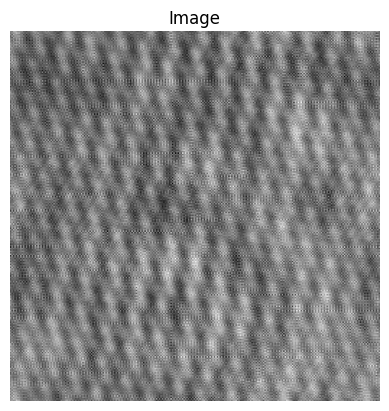

Image ID: 0127


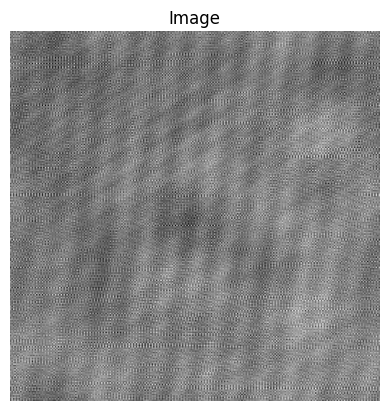

Image ID: 0128


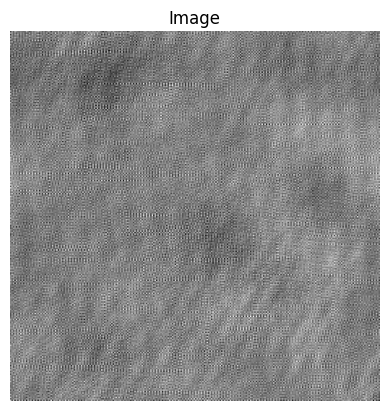

In [ ]:
keys = ["0123", "0124", "0129", "0125", "0130", "0126", "0127", "0128"]
rows = []
for key in keys:
    print("Image ID:" , key)
    output_path = f"/content/HAADF-STEM-image-denoising/Datasets/DATASET_WEI_ATOM_WS2_CONTRAST/denoised_pinto/"
    image_path = output_path + "Image_ID_" + key + "_denoised_pinto.tif"
    image = tifffile.imread(image_path)
    plt.imshow(image, cmap = "gray"); plt.axis("off"); plt.title("Image")
    plt.show()

In [ ]:
from scipy.optimize import OptimizeWarning  # HyperSpy relies on scipy optimization warnings
keys = ["0123", "0124", "0125", "0126", "0127", "0128", "0129", "0130"]
rows = []
for key in keys:
    print("Image ID:" , key)
    output_path = f"/content/HAADF-STEM-image-denoising/Datasets/DATASET_WEI_ATOM_WS2_CONTRAST/denoised_pinto/"
    image_path = output_path + "Image_ID_" + key + "_denoised_pinto.tif"
    image = convert(tifffile.imread(image_path))
    s = hs.load(image_path)
    noisy_sublattice = find_atoms(s, separation = SEPARATION, plot = True)
    plt.show()
    atom_data = []
    for atom in noisy_sublattice.atom_list:
      atom_data.append({
        'x': atom.pixel_x,
        'y': atom.pixel_y,
        'sx': atom.sigma_x,
        'sy': atom.sigma_y,
        'r': atom.rotation,
        'e': atom.ellipticity,
        'amplitude_gaussian': atom.amplitude_gaussian
       })

    with h5py.File(data_file, "r") as f:
        coordinates = f["coords"][key][:]

    reference_sublattice = am.sublattice.Sublattice(
        atom_position_list=coordinates,
        image=image
     )
    results = compare_sublattices_with_lattice_fp_classification(
        reference_sublattice,
        noisy_sublattice,
        image_shape=image.shape,
        match_tolerance=MATCH_TOLERANCE,
        lattice_tolerance=LATTICE_TOLERANCE,
        neighbor_radius=NEIGHBOR_RADIUS)
    plot_atom_classification(image, reference_sublattice, noisy_sublattice, results)
    contrast = metadata_subset.loc[metadata_subset["key"] == key, "contrast"].values[0]
    rows.append({"contrast": contrast, "rmse": np.round(results["rmse_error"], 2), "TP": results["num_true_positives"], "FN": results["num_false_negatives"], "FP": results["num_false_positives"] })

In [22]:
N_TP = len(reference_sublattice.atom_list)
df_results = pd.DataFrame(rows)
df_results = df_results.sort_values(by="contrast",ascending=False)
df_results['status'] = df_results.apply(
    lambda row: 'failed' if (row['FP'] > (0.5 * N_TP)) or (row['TP'] < (0.5 * N_TP)) else 'passed',
    axis=1
)
display(df_results)

,contrast,rmse,TP,FN,FP,status
0,0.159,0.96,295,2,140,passed
1,0.133,1.18,296,1,139,passed
6,0.109,1.37,277,20,58,passed
2,0.101,1.63,285,12,64,passed
7,0.087,1.98,271,26,90,passed
3,0.060,2.08,274,23,201,failed
4,0.048,3.12,228,69,418,failed
5,0.037,3.12,235,62,456,failed
